In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.amp import GradScaler, autocast
import matplotlib.pyplot as plt
import numpy as np
import random

# Configuração do dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando no dispositivo: {device}")

Treinando no dispositivo: cuda


In [50]:
# 1. ARQUITETURA DA REDE (Sua versão com BatchNorm e Dropout)
class ProjetoCNN(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super(ProjetoCNN, self).__init__()
        
        # Bloco 1
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        
        # Bloco 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout(0.25)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        # Classificador
        self.fc1 = nn.Linear(64 * 4 * 4, 512)
        self.dropout3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        x = self.fc2(x)
        return x

In [46]:
# 2. CONFIGURAÇÃO DE DADOS (CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset_cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader_cifar = torch.utils.data.DataLoader(trainset_cifar, batch_size=128, shuffle=True, 
                                          num_workers=2, pin_memory=True)

testset_cifar = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader_cifar = torch.utils.data.DataLoader(testset_cifar, batch_size=128, shuffle=False, 
                                         num_workers=2, pin_memory=True)

classes = ('avião', 'carro', 'pássaro', 'gato', 'veado', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão')

print(f"CIFAR-10 carregado! Treino: {len(trainset_cifar)} imagens")
print(f"Teste: {len(testset_cifar)} imagens")

/home/anselmo/projects/cnn/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR-10 carregado! Treino: 50000 imagens
Teste: 10000 imagens


In [ ]:
# 3. TREINAMENTO CIFAR-10 COM ACELERAÇÃO
modelo_cifar = ProjetoCNN(in_channels=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo_cifar.parameters(), lr=0.001, weight_decay=1e-4)

# Gerenciador de Precisão Mista
scaler = GradScaler('cuda') if device.type == 'cuda' else None
epocas = 15 
modelo_cifar.train()

print(f"\nIniciando treino CIFAR-10 ({epocas} épocas)...")
for epoch in range(epocas):
    running_loss = 0.0
    for imagens, rotulos in trainloader_cifar:
        # non_blocking=True agiliza a transferência CPU -> GPU
        imagens, rotulos = imagens.to(device, non_blocking=True), rotulos.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Execução em Precisão Mista (FP16)
        with autocast('cuda', enabled=(device.type == 'cuda')):
            saidas = modelo_cifar(imagens)
            loss = criterion(saidas, rotulos)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        
    print(f"Época {epoch+1}/{epocas} - Custo médio: {running_loss/len(trainloader_cifar):.4f}")



Iniciando treino CIFAR-10 (15 épocas)...
Época 1/15 - Custo médio: 1.4082
Época 2/15 - Custo médio: 1.0239
Época 3/15 - Custo médio: 0.8899
Época 4/15 - Custo médio: 0.8046
Época 5/15 - Custo médio: 0.7528
Época 6/15 - Custo médio: 0.7068
Época 7/15 - Custo médio: 0.6747
Época 8/15 - Custo médio: 0.6448
Época 9/15 - Custo médio: 0.6152
Época 10/15 - Custo médio: 0.5940
Época 11/15 - Custo médio: 0.5713
Época 12/15 - Custo médio: 0.5565
Época 13/15 - Custo médio: 0.5435
Época 14/15 - Custo médio: 0.5248
Época 15/15 - Custo médio: 0.5050


In [39]:
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset_mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
trainloader_mnist = torch.utils.data.DataLoader(trainset_mnist, batch_size=128, shuffle=True, 
                                                num_workers=2, pin_memory=True)

# Adicionando o conjunto de testes para o MNIST
testset_mnist = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)
testloader_mnist = torch.utils.data.DataLoader(testset_mnist, batch_size=128, shuffle=False, 
                                               num_workers=2, pin_memory=True)


print(f"MNIST carregado! Treino: {len(trainset_mnist)} imagens")
print(f"Teste: {len(testset_mnist)} imagens")

MNIST carregado! Treino: 60000 imagens
Teste: 10000 imagens


In [35]:
modelo_mnist = ProjetoCNN(in_channels=1).to(device)
optimizer_mnist = optim.Adam(modelo_mnist.parameters(), lr=0.001, weight_decay=1e-4)
scaler_mnist = GradScaler('cuda') if device.type == 'cuda' else None

epocas_mnist = 3
print(f"Iniciando treino MNIST ({epocas_mnist} épocas)...")

for epoch in range(epocas_mnist):
    modelo_mnist.train()
    running_loss = 0.0
    for imagens, rotulos in trainloader_mnist:
        imagens, rotulos = imagens.to(device, non_blocking=True), rotulos.to(device, non_blocking=True)
        
        optimizer_mnist.zero_grad(set_to_none=True)
        
        with autocast('cuda', enabled=(device.type == 'cuda')):
            saidas = modelo_mnist(imagens)
            loss = criterion(saidas, rotulos)
            
        scaler_mnist.scale(loss).backward()
        scaler_mnist.step(optimizer_mnist)
        scaler_mnist.update()
        
        running_loss += loss.item()
    
    print(f"Época {epoch+1}/{epocas_mnist} - Loss: {running_loss/len(trainloader_mnist):.4f}")

Iniciando treino MNIST (3 épocas)...
Época 1/3 - Loss: 0.2299
Época 2/3 - Loss: 0.0696
Época 3/3 - Loss: 0.0538


In [41]:
# --- 2. FUNÇÃO AUXILIAR DE AVALIAÇÃO ---
def avaliar_modelo(modelo, loader):
    """Calcula a acurácia percentual de um modelo num dado DataLoader."""
    modelo.eval()
    corretos = 0
    total = 0
    with torch.no_grad():
        for imagens, rotulos in loader:
            imagens, rotulos = imagens.to(device), rotulos.to(device)
            saidas = modelo(imagens)
            _, previstos = torch.max(saidas.data, 1)
            total += rotulos.size(0)
            corretos += (previstos == rotulos).sum().item()
    return 100 * corretos / total


In [51]:
acuracia_cifar = avaliar_modelo(modelo_cifar, testloader_cifar)
print(f"Acurácia final no CIFAR-10: {acuracia_cifar:.2f}%")

Acurácia final no CIFAR-10: 80.64%


In [43]:
acuracia_mnist = avaliar_modelo(modelo_mnist, testloader_mnist)
print(f"Acurácia final no MNIST: {acuracia_mnist:.2f}%")

Acurácia final no MNIST: 99.01%


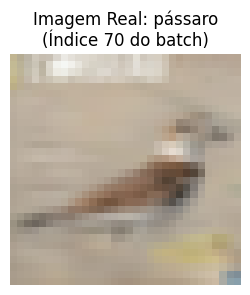

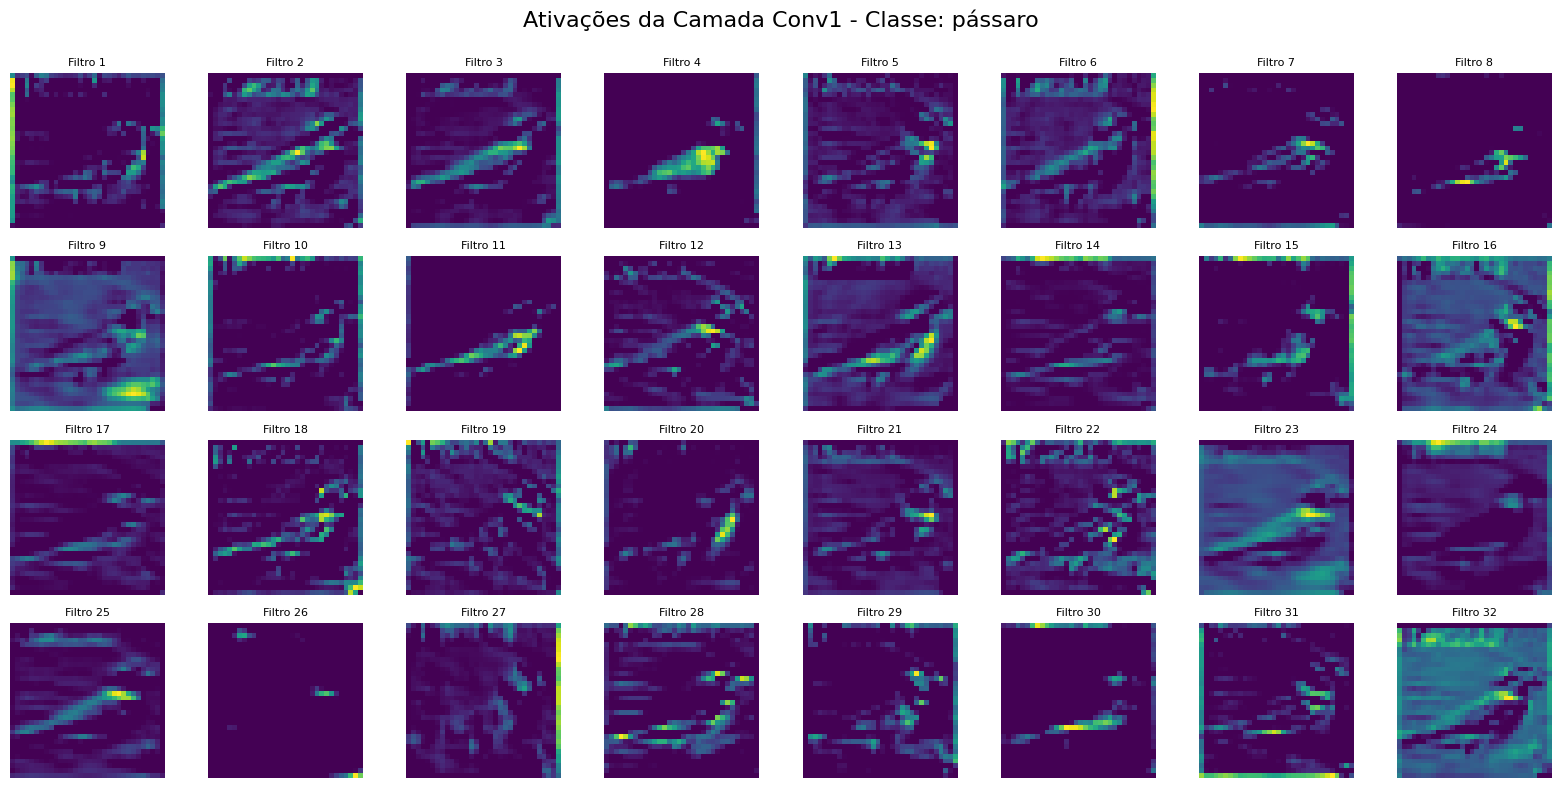

In [48]:
# 1. Pegar um lote de imagens e escolher uma aleatoriamente
dataiter = iter(testloader_cifar)
imagens, rotulos = next(dataiter)

# Define o tamanho do lote carregado
batch_size = imagens.shape[0]
# Seleciona um índice aleatório dentro do intervalo do lote
idx_aleatorio = random.randint(0, batch_size - 1)

# Pegar a imagem sorteada e preparar para a rede
img_original = imagens[idx_aleatorio]
img_tensor = img_original.unsqueeze(0).to(device) # Adiciona dimensão de batch [1, 3, 32, 32]
classe_real = classes[rotulos[idx_aleatorio]]

# 2. Extrair as ativações da PRIMEIRA camada convolucional
modelo_cifar.eval() # Modo de avaliação
with torch.no_grad():
    # Passamos a imagem pela conv1 e aplicamos ReLU para ver as ativações reais
    ativacoes = F.relu(modelo_cifar.conv1(img_tensor))

# O shape de 'ativacoes' será [1, 32, 32, 32]
# Removemos a dimensão do batch e jogamos para CPU
ativacoes = ativacoes.squeeze(0).cpu().numpy()

# 3. Plotar a imagem original para referência
img_display = img_original / 2 + 0.5 # Desnormaliza para visualização
npimg = img_display.numpy()
plt.figure(figsize=(3, 3))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.title(f'Imagem Real: {classe_real}\n(Índice {idx_aleatorio} do batch)')
plt.axis('off')
plt.show()

# 4. Plotar os 32 Feature Maps (4 linhas x 8 colunas)
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle(f'Ativações da Camada Conv1 - Classe: {classe_real}', fontsize=16)

for i, ax in enumerate(axes.flat):
    # Usamos o mapa de cores 'viridis' para destacar as ativações
    ax.imshow(ativacoes[i], cmap='viridis') 
    ax.axis('off')
    ax.set_title(f'Filtro {i+1}', fontsize=8)

plt.tight_layout()
plt.subplots_adjust(top=0.9) # Ajusta o espaço para o título principal
plt.show()

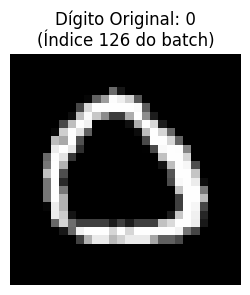

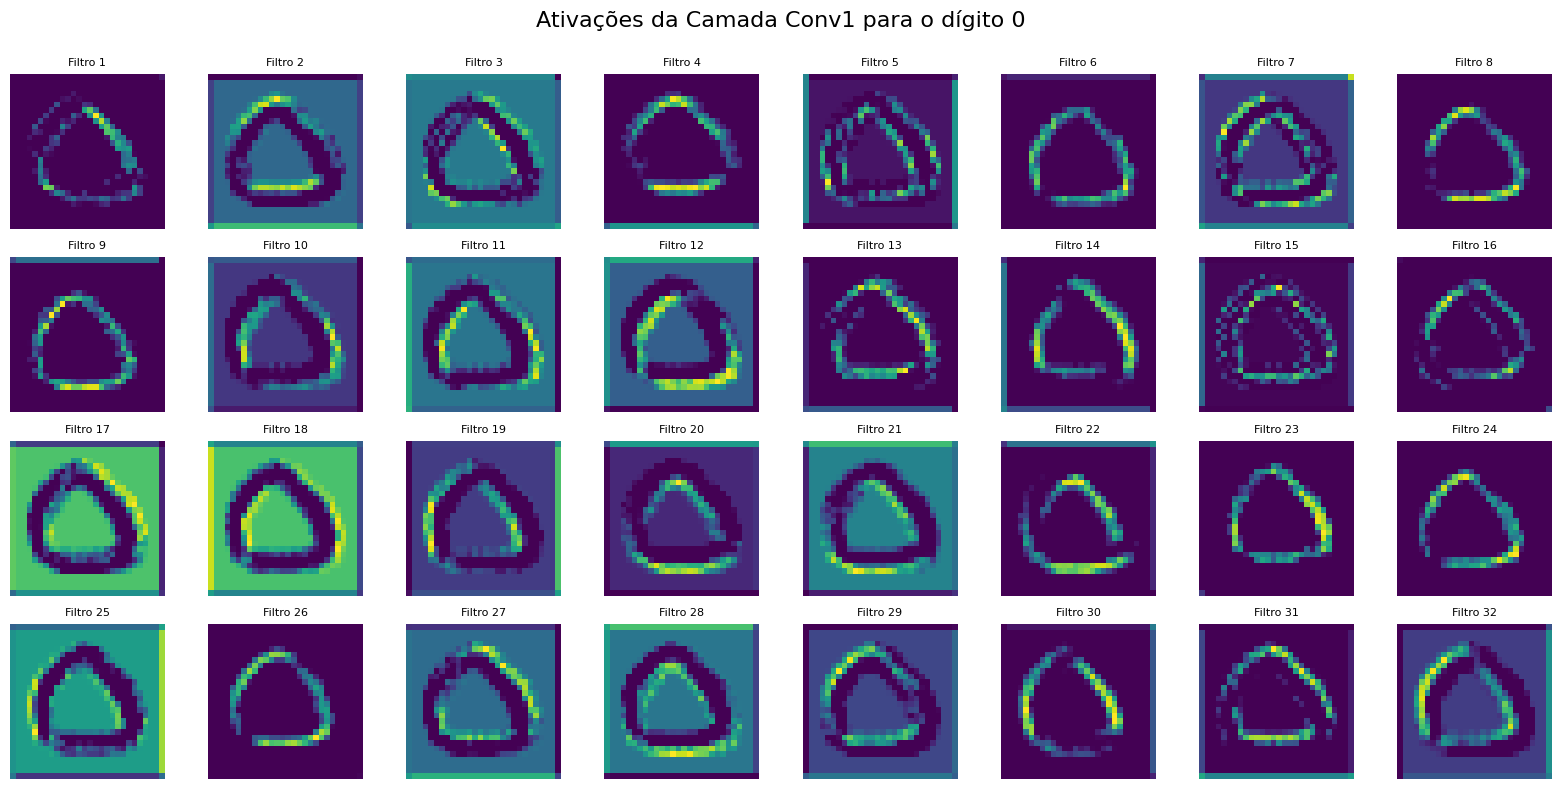

In [38]:
# 1. Preparação: Colocar o modelo em modo de avaliação (desativa Dropout)
modelo_mnist.eval()

# 2. Pegar um lote de imagens do conjunto de testes (testloader_mnist)
dataiter = iter(testloader_mnist)
imagens, rotulos = next(dataiter)

# Define o tamanho do lote carregado e seleciona um índice aleatório
batch_size = imagens.shape[0]
idx_aleatorio = random.randint(0, batch_size - 1)

# Selecionamos a imagem sorteada do lote
img_original = imagens[idx_aleatorio]
label_real = rotulos[idx_aleatorio].item()

# Preparamos o tensor para a rede (adicionando dimensão de batch e enviando para o dispositivo)
img_tensor = img_original.unsqueeze(0).to(device)

# 3. EXTRAÇÃO DAS ATIVAÇÕES
with torch.no_grad():
    # Passamos a imagem APENAS pela primeira camada convolucional e aplicamos a ReLU
    ativacoes = F.relu(modelo_mnist.conv1(img_tensor))

# O formato de 'ativacoes' será [1, 32, 28, 28]
# Removemos a dimensão de batch e movemos para CPU/Numpy para plotar
ativacoes = ativacoes.squeeze(0).cpu().numpy()

# --- PLOTAGEM DOS RESULTADOS ---

# 4. Plotar a imagem original para referência
# Desnormalização: original = normalized * std + mean (0.5, 0.5)
img_display = img_original.cpu() * 0.5 + 0.5
img_np = img_display.squeeze(0).numpy() # Remove canal de entrada [28, 28]

plt.figure(figsize=(3, 3))
# Usamos cmap='gray' porque o MNIST é monocromático
plt.imshow(img_np, cmap='gray') 
plt.title(f'Dígito Original: {label_real}\n(Índice {idx_aleatorio} do batch)')
plt.axis('off')
plt.show()

# 5. Plotar os 32 Feature Maps (Ativações)
# Criamos uma grade 4x8 para acomodar os 32 filtros
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle(f'Ativações da Camada Conv1 para o dígito {label_real}', fontsize=16)

# Iteramos sobre os subplots e os 32 canais de ativação
for i, ax in enumerate(axes.flat):
    if i < 32:
        # Usamos cmap='viridis' para destacar a intensidade da ativação
        ax.imshow(ativacoes[i], cmap='viridis')
        ax.set_title(f'Filtro {i+1}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()